# Finding what you were never taught to find

### ZTF Summer School — machine learning for transient discovery

Modern surveys like ZTF (and soon LSST) detect far more transients each night
than humans can inspect. Machine-learning classifiers handle the known classes —
but the most exciting objects are the ones **nobody trained the classifier on**.

This session has two acts:

- **Act 1 — the known unknowns.** We classify ZTF light curves into five classes
  (SNI, SNII, CV, AGN, TDE) with FLARE: physics features + gradient-boosted trees.
- **Act 2 — the unknown unknowns.** We take a version of the model trained
  **without any TDEs** — for this model, tidal disruption events do not exist —
  and use the anomaly-detection package **LUNA** to *discover* them anyway.

Requirements: the `flare` package (with its bundled weights) and
`pip install git+https://github.com/asasli/luna`. Data: the ZTF `photo_events`
directory (set `FLARE_DATA` or edit `DATA_DIR` below).

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")            # the flare package
from flare import FlareClassifier, BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Setup OK")

Setup OK


## Act 1 — classifying the known classes

Each ZTF object is a **light curve**: brightness measured at irregular times in
the g and r bands. FLARE converts every light curve into **160 physics features**
(colours, timescales, smoothness, explosion-fit parameters) and classifies them
with a gradient-boosted tree ensemble. Let's see it work end to end.

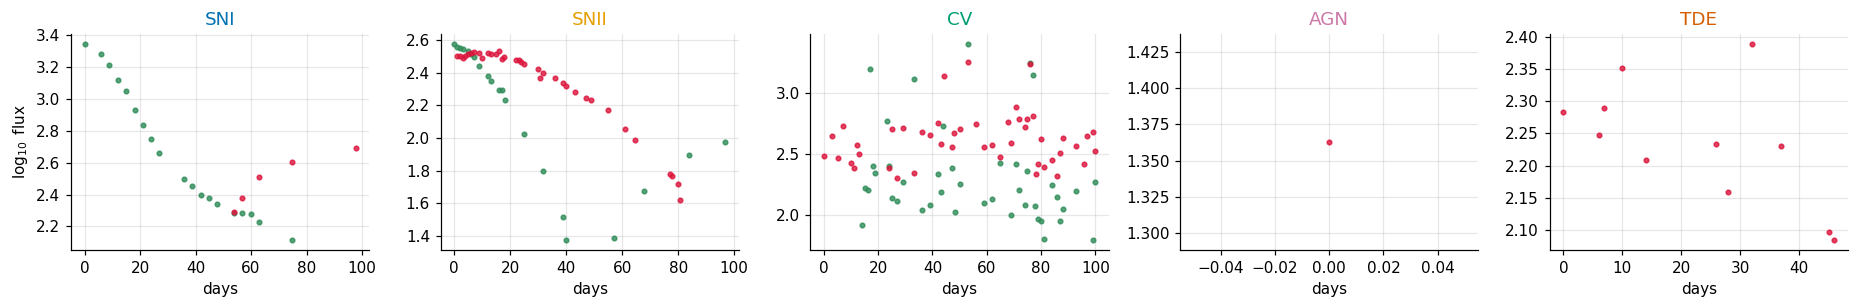

In [2]:
# One real example per class
manifest = D.load_manifest("test")
manifest["broad"] = manifest["label"].map(lambda x: BROAD_CLASSES[ID2BROAD_ID[int(x)]])

fig, axes = plt.subplots(1, 5, figsize=(17, 2.9))
for ax, cls in zip(axes, BROAD_CLASSES):
    row = manifest[manifest.broad == cls].nlargest(1, "n_events").iloc[0]
    bands = D.reconstruct_bands(D.load_events(row.filepath))
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3, color=colr, alpha=0.8)
    ax.set_title(cls, color=CLASS_COLOR[cls])
    ax.set_xlabel("days")
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.tight_layout(); plt.show()

In [3]:
# The full 5-class model: features -> trees -> probabilities
clf5 = FlareClassifier.from_pretrained()
kept, _ = D.filter_manifest_quality(manifest)
y_true = np.array([ID2BROAD_ID[int(l)] for l in kept.label])

X_test_raw = clf5.features_from_files(kept.filepath.tolist())   # ~1 min
P5 = clf5.predict_proba(X_test_raw)
print(f"test objects: {len(y_true)}  |  accuracy: {(P5.argmax(1) == y_true).mean():.3f}")
print("\nper-class recall:")
for c, name in enumerate(BROAD_CLASSES):
    m = y_true == c
    print(f"  {name:5s} (n={m.sum():4d}): {(P5.argmax(1)[m] == c).mean():.2f}")

E20260726 13:30:57.612037 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260726 13:30:57.728479 849631 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260726 13:30:57.728523 849631 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260726 13:30:57.728646 849631 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260726 13:30:57.728660 849631 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.


E20260726 13:30:57.976123 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 13:30:58.705947 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 13:30:59.033712 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 13:30:59.919167 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260726 13:31:00.019879 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


...

E20260726 13:31:04.079960 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260726 13:31:04.214468 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 13:31:04.388275 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260726 13:31:04.436301 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 13:31:04.639216 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 13:31:05.482003 849631 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


test objects: 1979  |  accuracy: 0.957

per-class recall:
  SNI   (n= 886): 0.97
  SNII  (n= 219): 0.84
  CV    (n=  91): 0.91
  AGN   (n= 774): 0.98
  TDE   (n=   9): 0.33


Strong performance on the common classes — and note the hardest one is **TDE**,
with only 9 examples in this test set. Which raises the real question of Act 2:

> What if TDEs had *never been discovered*? Could the machine have found them
> for us?

## Act 2 — the unknown unknowns

We trained a second model (`train_no_tde.py`) on the **same data with every TDE
removed**, from both training and validation. Four classes: SNI, SNII, CV, AGN.
Its 4-class accuracy is 0.955 — a perfectly good classifier.

To this model, the class "TDE" does not exist. Let's push the 9 real TDEs
through it and watch what happens.

In [4]:
KNOWN = ["SNI", "SNII", "CV", "AGN"]
clf4 = FlareClassifier.from_pretrained(
    model_path="../../models/flare_lgbm_no_tde.txt",
    conformal_path="/nonexistent")

is_tde = y_true == BROAD_CLASSES.index("TDE")
P4 = clf4.predict_proba(X_test_raw)               # (N, 4) — TDE is not an option

tab = pd.DataFrame(P4[is_tde], columns=KNOWN,
                   index=kept.obj_id[is_tde]).round(2)
tab["prediction"] = [KNOWN[i] for i in P4[is_tde].argmax(1)]
print(tab.to_string())
print(f"\nmean confidence on the 9 TDEs   : {P4[is_tde].max(1).mean():.2f}")
print(f"mean confidence on everything else: {P4[~is_tde].max(1).mean():.2f}")

               SNI  SNII    CV   AGN prediction
obj_id                                         
ZTF21abcgnqn  0.32  0.20  0.03  0.45        AGN
ZTF24aazlori  0.01  0.01  0.00  0.98        AGN
ZTF21abhrchb  0.59  0.30  0.00  0.11        SNI
ZTF21abowtqx  0.00  0.01  0.00  0.99        AGN
ZTF18acaqdaa  0.05  0.08  0.10  0.77        AGN
ZTF22aaaedas  0.22  0.13  0.08  0.58        AGN
ZTF20abgbdpr  0.04  0.21  0.03  0.72        AGN
ZTF20abowque  0.03  0.11  0.01  0.86        AGN
ZTF19aatylnl  0.06  0.54  0.07  0.33       SNII

mean confidence on the 9 TDEs   : 0.72
mean confidence on everything else: 0.96


The TDEs get absorbed into the known classes — mostly AGN — but the model is
measurably *less confident* about them (0.72 vs 0.96). It cannot name what it
has never seen, but it hesitates. Anomaly detection turns that hesitation, plus
the geometry of the feature space, into a **discovery signal**.

### LUNA: sixteen ways to be surprised

[LUNA](https://github.com/asasli/luna) is a classifier-agnostic
out-of-distribution detection package. Given a model's **embeddings** (here: the
160 scaled physics features) and **logits** (the trees' raw class scores), it
computes a battery of anomaly scores from four families:

| family | idea | examples |
|---|---|---|
| uncertainty | "the classifier hesitates" | MSP, entropy, energy |
| distance | "far from every training cluster" | Mahalanobis, kNN |
| density | "in a low-density region" | GMM, isolation forest, LOF |
| hybrid | combinations of the above | HEC, MRS |

No single score is best for every kind of anomaly — that is why LUNA computes
them all.

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from luna.pipeline import LUNAPipeline

# --- build LUNA inputs from the no-TDE world ---------------------------------
# training features (cached by train_no_tde.py; extraction takes ~1 min otherwise)
tr = pd.read_parquet("../../artifacts/features_train_h100.parquet")
ytr = tr["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
Xtr_raw = tr.drop(columns=["obj_id", "label"])
no_tde = ytr != BROAD_CLASSES.index("TDE")
Xtr_raw, ytr4 = Xtr_raw[no_tde], ytr[no_tde]

imputer = SimpleImputer(strategy="median").fit(Xtr_raw)
scaler  = RobustScaler().fit(imputer.transform(Xtr_raw))
embed = lambda Xdf: np.clip(scaler.transform(imputer.transform(Xdf)), -10, 10)
logits = lambda Xdf: clf4.booster.predict(Xdf, raw_score=True)   # (N, 4)

train_data = {"embeddings": embed(Xtr_raw), "labels": ytr4, "logits": logits(Xtr_raw)}

# The discovery pool: every TDE that neither the model nor LUNA will ever train
# on — the 9 test TDEs PLUS the 47 train TDEs we excluded from everything.
tde_tr = tr[~no_tde].reset_index(drop=True)          # the 47 excluded train TDEs
X_query_raw = pd.concat([X_test_raw.reset_index(drop=True),
                         tde_tr.drop(columns=["obj_id", "label"])],
                        ignore_index=True)[X_test_raw.columns]
train_fp = D.load_manifest("train").set_index("obj_id").filepath
query_ids = np.concatenate([kept.obj_id.values, tde_tr.obj_id.values])
query_fp  = np.concatenate([kept.filepath.values, train_fp.loc[tde_tr.obj_id].values])
truth_q   = np.concatenate([[BROAD_CLASSES[i] for i in y_true], ["TDE"] * len(tde_tr)])
is_tde_q  = truth_q == "TDE"

query_data = {"embeddings": embed(X_query_raw), "logits": logits(X_query_raw)}
print(f"LUNA train: {train_data['embeddings'].shape}  |  "
      f"query pool: {query_data['embeddings'].shape[0]} objects, "
      f"{is_tde_q.sum()} hidden TDEs (9 test + 47 train-excluded)")

LUNA train: (9170, 160)  |  query pool: 2026 objects, 56 hidden TDEs (9 test + 47 train-excluded)


In [6]:
pipe = LUNAPipeline(target_far=0.01)
pipe.fit(train_data)                      # learns what 'normal' looks like
scores = pipe.score(query_data)           # 14 anomaly scores per pool object
print("scorers:", list(scores))

  [LUNA] fit msp in 0.0s


  [LUNA] fit entropy in 0.0s


  [LUNA] fit energy in 0.0s


  [LUNA] fit odin in 0.0s


  [LUNA] fit mahal_global in 0.0s


...

  [LUNA] fit lof in 0.2s


  [LUNA] fit pca_recon in 0.0s


  [LUNA] fit mrs in 0.0s


  [LUNA] Fitted 14 scorers: ['msp', 'entropy', 'energy', 'odin', 'mahal_global', 'mahal_class', 'mahal_within', 'knn', 'typicality', 'gmm', 'iforest', 'lof', 'pca_recon', 'mrs']


scorers: ['msp', 'entropy', 'energy', 'odin', 'mahal_global', 'mahal_class', 'mahal_within', 'knn', 'typicality', 'gmm', 'iforest', 'lof', 'pca_recon', 'mrs']


### Do the individual scores react to the TDEs?

For each scorer we compare its distribution on the TDEs (which LUNA has never
seen, in any form) against everything else.

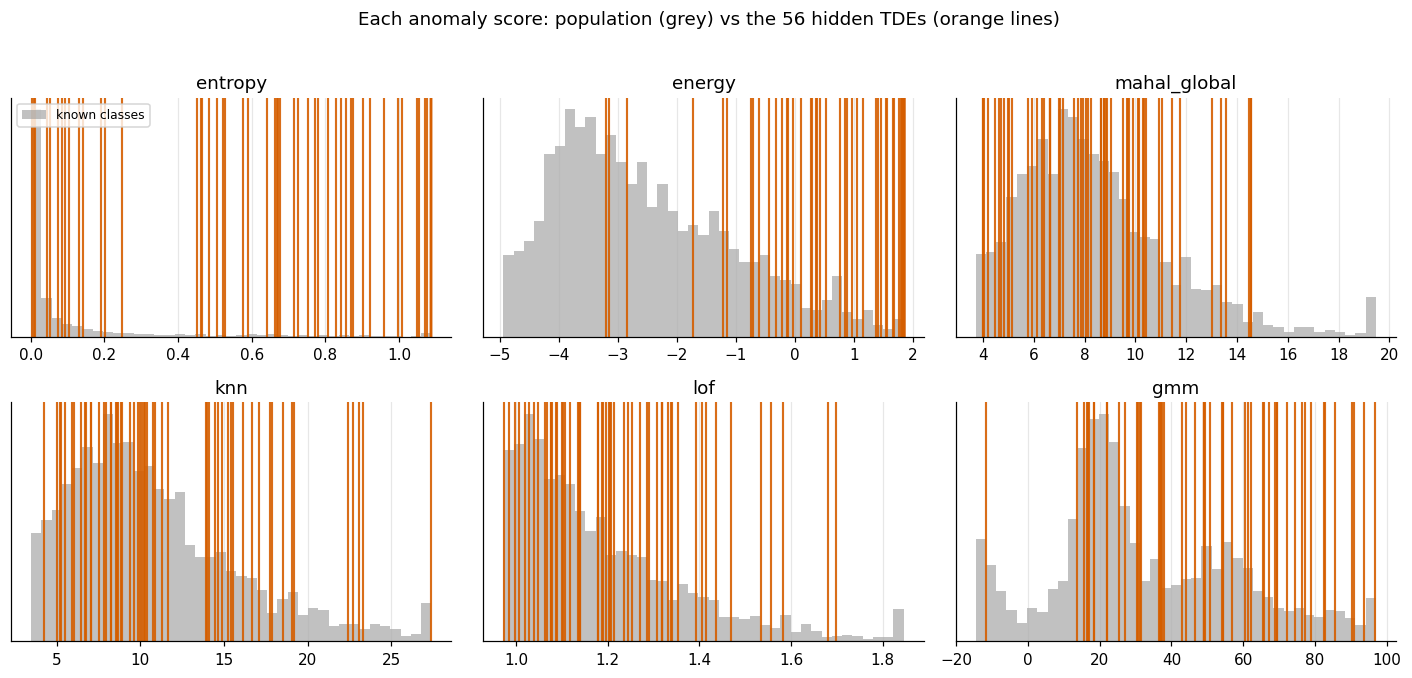

In [7]:
show = ["entropy", "energy", "mahal_global", "knn", "lof", "gmm"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, name in zip(axes.ravel(), show):
    s = scores[name]
    lo, hi = np.percentile(s, [1, 99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(np.clip(s[~is_tde_q], lo, hi), bins=bins, density=True, alpha=0.6,
            color="0.6", label="known classes")
    for v in s[is_tde_q]:
        ax.axvline(np.clip(v, lo, hi), color=CLASS_COLOR["TDE"], lw=1.4, alpha=0.9)
    ax.set_title(name)
    ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
fig.suptitle("Each anomaly score: population (grey) vs the 56 hidden TDEs (orange lines)", y=1.02)
plt.tight_layout(); plt.show()

Most orange lines sit in the right tails — each scorer family is somewhat
surprised by the TDEs, for different reasons.

### Stage 1 — blind discovery (no known anomalies at all)

Pretend it is 1995 and nobody knows TDEs exist. We have no labels to tune a
combination, so we use the most robust unsupervised aggregate: convert every
score to a **rank** and average the ranks. Objects that many scorers find
strange rise to the top.

In [8]:
from scipy.stats import rankdata

R = np.mean([rankdata(scores[k]) for k in scores], axis=0)   # consensus rank
order = np.argsort(R)[::-1]

topk = 40
n_found = is_tde_q[order[:topk]].sum()
print(f"top-{topk} consensus anomalies contain {n_found}/{is_tde_q.sum()} of the hidden TDEs")
print(f"(random chance would give {topk * is_tde_q.sum() / len(is_tde_q):.1f})\n")

from sklearn.metrics import roc_auc_score
print(f"TDE-vs-rest AUC of the blind consensus: {roc_auc_score(is_tde_q, R):.3f}")

print("\nrank  object          truth   consensus")
for r, i in enumerate(order[:15]):
    mark = "  <-- hidden TDE" if is_tde_q[i] else ""
    print(f"  {r+1:2d}  {query_ids[i]:15s} {truth_q[i]:5s}  {R[i]:8.1f}{mark}")

top-40 consensus anomalies contain 6/56 of the hidden TDEs
(random chance would give 1.1)

TDE-vs-rest AUC of the blind consensus: 0.718

rank  object          truth   consensus
   1  ZTF23abkhwgb    SNII     1996.9
   2  ZTF23aaawbsc    SNII     1982.1
   3  ZTF20abjawew    AGN      1972.9
   4  ZTF19aaloayl    AGN      1968.5
   5  ZTF23aaklqou    SNII     1944.5
   6  ZTF22aamgumi    SNII     1940.6
   7  ZTF18aaaadvs    AGN      1938.1
   8  ZTF18acpoocp    CV       1924.5
   9  ZTF17aaasklh    CV       1924.3
  10  ZTF19aavqcpp    CV       1920.9
  11  ZTF22aaimgkp    TDE      1916.5  <-- hidden TDE
  12  ZTF20achpcvt    TDE      1914.9  <-- hidden TDE
  13  ZTF19acspeuw    TDE      1904.7  <-- hidden TDE
  14  ZTF22aagyuao    TDE      1903.4  <-- hidden TDE
  15  ZTF22aahgubb    SNII     1900.0


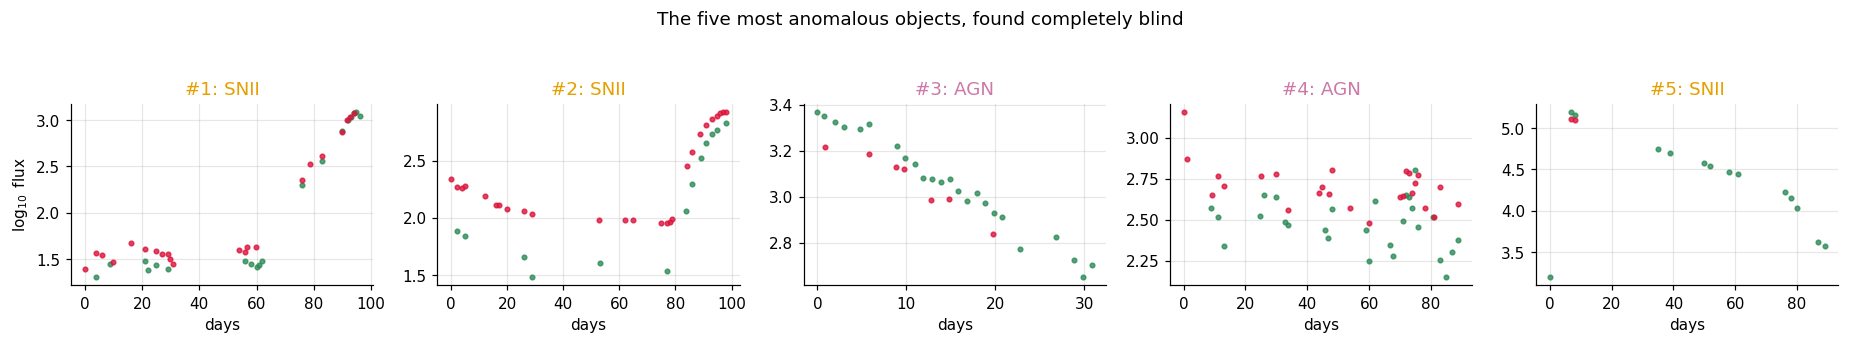

In [9]:
# Look at the top blind candidates
fig, axes = plt.subplots(1, 5, figsize=(17, 2.9))
for ax, i in zip(axes, order[:5]):
    bands = D.reconstruct_bands(D.load_events(query_fp[i]))
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3, color=colr, alpha=0.8)
    ax.set_title(f"#{list(order).index(i)+1}: {truth_q[i]}", color=CLASS_COLOR[truth_q[i]])
    ax.set_xlabel("days")
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.suptitle("The five most anomalous objects, found completely blind", y=1.06)
plt.tight_layout(); plt.show()

The blind consensus has real signal: 6 of the 56 hidden TDEs appear in the
top-40 candidates — about six times more than chance — and the TDE-vs-rest AUC
is 0.72. But it is far from a targeted search: most top candidates are *generic*
strangeness (extreme, sparse, or contaminated light curves). The lesson is that
**anomalous is not the same as interesting**: averaging all fourteen scorers
dilutes the few that actually react to TDEs (Exercise 2 asks which ones those
are). Blind search tells you *where to look*; it rarely hands you a specific new
class on a plate.

Historically this is how it works: follow up a handful of odd candidates,
confirm a few spectroscopically, and *then* search in a targeted way. That is
Stage 2.

### Stage 2 — a few known examples change everything

Suppose spectra have confirmed a few candidates as a genuinely new class. Can
those examples sharpen the search?

The **validation split** contains 9 TDEs that the no-TDE model never trained
on. We give them to LUNA's supervised combiner (`fit_combiner`), which learns
the optimal weighting of the 14 scores and calibrates a detection threshold at
a 1% false-alarm rate.

**Data hygiene** — this evaluation is honest by construction: the combiner is
fitted *only* on validation objects (1,982 normal + the 9 confirmed TDEs),
while the discovery pool we evaluate on (test split + the 47 train-excluded
TDEs) shares **no object** with the combiner's training data. Performance
below is therefore measured on fully independent data.

In [10]:
# validation data: in-distribution part + the 9 'newly confirmed' TDEs
va = pd.read_parquet("../../artifacts/features_val_h100.parquet")
yva = va["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
Xva_raw = va.drop(columns=["obj_id", "label"])
va_tde = yva == BROAD_CLASSES.index("TDE")

id_data  = {"embeddings": embed(Xva_raw[~va_tde]), "logits": logits(Xva_raw[~va_tde])}
ood_data = {"embeddings": embed(Xva_raw[va_tde]),  "logits": logits(Xva_raw[va_tde])}
print(f"combiner training: {len(yva) - va_tde.sum()} normal + {va_tde.sum()} confirmed TDEs")

pipe.fit_combiner(id_data, ood_data, verbose=False)
out = pipe.predict(query_data)
es = out["ensemble_score"]

print(f"\nsupervised ensemble AUC : {roc_auc_score(is_tde_q, es):.3f}"
      f"   (blind consensus was {roc_auc_score(is_tde_q, R):.3f})")
flag = out["flagged"]
print(f"flagged at 1% FAR       : {flag.sum()} objects, "
      f"containing {is_tde_q[flag].sum()}/{is_tde_q.sum()} TDEs")
topk = 40
print(f"top-{topk} now contains     : {is_tde_q[np.argsort(es)[::-1][:topk]].sum()}/{is_tde_q.sum()} TDEs")

combiner training: 1982 normal + 9 confirmed TDEs



supervised ensemble AUC : 0.905   (blind consensus was 0.718)
flagged at 1% FAR       : 49 objects, containing 20/56 TDEs
top-40 now contains     : 18/56 TDEs


With only nine labelled examples the picture transforms — on a fully
independent evaluation pool: AUC rises from 0.72 to **0.91**; the top-40 now
contains **18 of the 56** hidden TDEs (45% precision, versus 6 blind); and at a
1% false-alarm rate just 49 objects are flagged, containing 20 TDEs. This is
the *active-learning loop* of a real survey: search blind, confirm a few,
retrain the detector, search again.

## What you learned

1. A classifier can only name the classes it was trained on; rare new
   phenomena get silently absorbed into the nearest known class.
2. The model still leaves fingerprints: lower confidence, unusual positions in
   feature space, low local density. **Anomaly scores** formalise these.
3. Blind consensus finds *generic* strangeness — several times better than
   chance, but anomalous does not mean interesting; averaging everything
   dilutes the informative scorers.
4. A handful of confirmed examples turns anomaly detection into a targeted
   search — evaluated on data fully independent of everything that was fitted
   (model, scorers, combiner): AUC 0.72 to 0.91 with nine labels.

### Exercises

1. **Precision-K curve.** Plot the number of TDEs found vs the number of
   candidates inspected (K = 1..200) for the blind and supervised rankings.
2. **Which scorer family matters most?** Compute the TDE-vs-rest AUC of each
   individual scorer. Are the winners uncertainty-, distance-, or density-based?
   Would a consensus over only the best family beat the all-scorer average?
3. **A different hidden class.** Retrain the 4-class model hiding **CV** instead
   of TDE (edit `train_no_tde.py`). Is a repeating-outburst class easier or
   harder to discover as an anomaly than a smooth one-off event? Why?
4. **Early discovery.** Rebuild the embeddings from day-10 features
   (`horizon_days=10`). Can you still find the TDEs before they peak?

---
*Packages: [FLARE](https://github.com/appleapplecider-ml/flare) and
[LUNA](https://github.com/asasli/luna). See also the companion notebooks
`flare_tutorial.ipynb` and `similarity_search.ipynb`.*